In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


df = pd.read_csv("../data/processed/reviews_with_summaries.csv")


texts = df["text_for_topics"].dropna()

vectorizer = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2)
)


dtm = vectorizer.fit_transform(texts)

print("DTM shape:", dtm.shape)

DTM shape: (5000, 912)


In [13]:
topic_range = range(4, 16)
perplexities = []

for n in topic_range:
    lda = LatentDirichletAllocation(
        n_components=n,
        max_iter=20,
        learning_method='online',
        random_state=42
    )
    
    lda.fit(dtm)
    perplexities.append(lda.perplexity(dtm))
    print(f"Topics: {n}, Perplexity: {perplexities[-1]:.2f}")

Topics: 4, Perplexity: 238.68
Topics: 5, Perplexity: 216.45
Topics: 6, Perplexity: 202.90
Topics: 7, Perplexity: 178.75
Topics: 8, Perplexity: 165.25
Topics: 9, Perplexity: 153.13
Topics: 10, Perplexity: 141.56
Topics: 11, Perplexity: 129.73
Topics: 12, Perplexity: 123.14
Topics: 13, Perplexity: 121.13
Topics: 14, Perplexity: 111.27
Topics: 15, Perplexity: 106.86


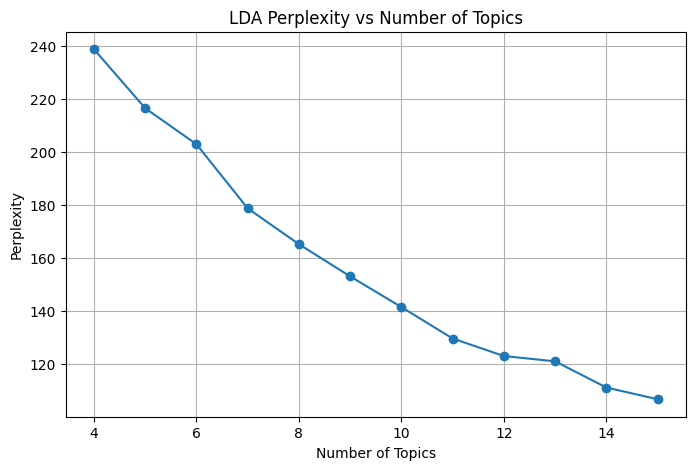

In [14]:
plt.figure(figsize=(8,5))
plt.plot(topic_range, perplexities, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("LDA Perplexity vs Number of Topics")
plt.grid(True)
plt.show()

we should try 8 10 12 topics and check the top words 

In [15]:
import os 
import sys 
sys.path.append(os.path.abspath(".."))

from src.topic_model import train_lda_model
lda_8, _ = train_lda_model(dtm, vectorizer, n_topics=8)
lda_10, _ = train_lda_model(dtm, vectorizer, n_topics=10)
lda_12, _ = train_lda_model(dtm, vectorizer, n_topics=12)


===== LDA Model with 8 Topics =====
Perplexity: 165.25

Topic 0: perfectly arrive, time buy, work perfectly, perfectly, buy, love, arrive time, time, arrive, work
Topic 1: build easy, family, set family, family love, easy set, love, build, lead, star, easy
Topic 2: good, advertise happy, purchase year, good purchase, advertise, product, easy, work exactly, exactly, work
Topic 3: cloudpillow, maker, instabrew coffee, instabrew, coffee, coffee maker, set, airpurifier promax, airpurifier, promax
Topic 4: recommend, way highly, expectation way, way, great product, highly, highly recommend, exceed, quality, great
Topic 5: softtouch luxury, softtouch, towel set, towel, set, bluetooth, soundbar, soundbar x200, x200 bluetooth, x200
Topic 6: shape, shape sectional, sectional, bed frame, bed, frame, frame queen, queen, woodcraft, woodcraft bed
Topic 7: mattress, memory foam, skeptical, impressive, fast, impressive fast, genuinely impressive, fast delivery, genuinely, delivery

===== LDA Model w

In [16]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model = LatentDirichletAllocation(
        n_components=10,
        max_iter=20,
        learning_method="online",
        random_state=42
    )

lda_model.fit(dtm)

perplexity = lda_model.perplexity(dtm)

In [19]:
topic_distributions = lda_model.transform(dtm)

df = df.loc[texts.index]  # align index if dropna used
df["dominant_topic"] = topic_distributions.argmax(axis=1)
df["topic_confidence"] = topic_distributions.max(axis=1)

df.head()
df.to_csv("../data/processed/reviews_with_summaries.csv", index=False)

In [20]:
topic_labels = {
    0: "Delivery & Arrival",
    1: "Ease of Setup",
    2: "Daily Use Satisfaction",
    3: "Kitchen & Appliance Products",
    4: "Build Quality",
    5: "Product Accuracy",
    6: "Furniture & Frames",
    7: "Mattress & Comfort",
    8: "Recommendation & Value",
    9: "Mixed Product Category"
}

df['topic_label'] = df['dominant_topic'].map(topic_labels)
df.to_csv("../data/processed/reviews_with_summaries.csv", index=False)

In [9]:
# Percentage of reviews per topic
topic_summary = (
    df['topic_label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(topic_summary)

topic_label
Build Quality                   22.74
Daily Use Satisfaction          17.80
Delivery & Arrival              14.08
Recommendation & Value          10.48
Product Accuracy                 9.88
Mixed Product Category           7.78
Ease of Setup                    6.96
Furniture & Frames               4.54
Mattress & Comfort               3.62
Kitchen & Appliance Products     2.12
Name: proportion, dtype: float64


In [23]:
print(df['topic_label'].unique)

<bound method Series.unique of 0           Delivery & Arrival
1       Daily Use Satisfaction
2           Delivery & Arrival
3       Recommendation & Value
4           Furniture & Frames
                 ...          
4995        Delivery & Arrival
4996        Mattress & Comfort
4997    Recommendation & Value
4998             Ease of Setup
4999          Product Accuracy
Name: topic_label, Length: 5000, dtype: str>


In [25]:
import pickle

with open("topic_model.pkl", "wb") as f:
    pickle.dump((lda_model, vectorizer), f)

pickle.dump(vectorizer,open("vectorizer.pkl","wb"))